In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import optuna
import joblib
from pathlib import Path

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_recall_curve
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Librerías cargadas")

Librerías cargadas


In [2]:
PROJECT_ROOT   = Path(".").resolve().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR     = PROJECT_ROOT / "models"

X_train = pd.read_parquet(DATA_PROCESSED / "X_train.parquet")
X_val   = pd.read_parquet(DATA_PROCESSED / "X_val.parquet")
X_test  = pd.read_parquet(DATA_PROCESSED / "X_test.parquet")

y_train = pd.read_parquet(DATA_PROCESSED / "y_train.parquet").squeeze()
y_val   = pd.read_parquet(DATA_PROCESSED / "y_val.parquet").squeeze()
y_test  = pd.read_parquet(DATA_PROCESSED / "y_test.parquet").squeeze()

print(f"X_train: {X_train.shape}  |  fraude: {y_train.mean()*100:.2f}%")
print(f"X_val:   {X_val.shape}  |  fraude: {y_val.mean()*100:.2f}%")
print(f"X_test:  {X_test.shape}  |  fraude: {y_test.mean()*100:.2f}%")

X_train: (413378, 422)  |  fraude: 3.50%
X_val:   (88581, 422)  |  fraude: 3.50%
X_test:  (88581, 422)  |  fraude: 3.50%


In [3]:
mlflow.set_tracking_uri("file:///" + str(PROJECT_ROOT / "mlruns").replace("\\", "/"))
mlflow.set_experiment("fraudshield-optuna")

print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experimento:  fraudshield-optuna")

Tracking URI: file:///C:/Users/micke/OneDrive/Desktop/projects/Frauddetection-mlops/mlruns
Experimento:  fraudshield-optuna


In [4]:
def objective_xgb(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 500),
        "max_depth":         trial.suggest_int("max_depth", 3, 6),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1.0, 10.0, log=True),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1.0, 10.0, log=True),
        "scale_pos_weight":  trial.suggest_float("scale_pos_weight", 1.0, 10.0),
        "random_state": 42, "n_jobs": -1,
        "eval_metric": "aucpr", "verbosity": 0,
        "early_stopping_rounds": 20
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return average_precision_score(y_val, model.predict_proba(X_val)[:, 1])


def objective_lgbm(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 500),
        "max_depth":         trial.suggest_int("max_depth", 3, 6),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1.0, 10.0, log=True),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1.0, 10.0, log=True),
        "scale_pos_weight":  trial.suggest_float("scale_pos_weight", 1.0, 10.0),
        "random_state": 42, "n_jobs": -1, "verbose": -1
    }
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)
    return average_precision_score(y_val, model.predict_proba(X_val)[:, 1])


def objective_cat(trial):
    params = {
        "iterations":        trial.suggest_int("iterations", 100, 500),
        "depth":             trial.suggest_int("depth", 3, 6),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1.0, 10.0, log=True),
        "scale_pos_weight":  trial.suggest_float("scale_pos_weight", 1.0, 10.0),
        "random_seed": 42, "verbose": 0
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train)
    return average_precision_score(y_val, model.predict_proba(X_val)[:, 1])

print("Funciones objetivo definidas")

Funciones objetivo definidas


In [5]:
study_xgb  = optuna.create_study(direction="maximize")
study_lgbm = optuna.create_study(direction="maximize")
study_cat  = optuna.create_study(direction="maximize")

configs = [
    ("XGBoost",  objective_xgb,  study_xgb),
    ("LightGBM", objective_lgbm, study_lgbm),
    ("CatBoost", objective_cat,  study_cat),
]

for name, objective, study in configs:
    print(f"\nOptimizando {name} — 30 trials...")
    with mlflow.start_run(run_name=f"{name}_optuna"):
        study.optimize(objective, n_trials=30)
        mlflow.log_params(study.best_params)
        mlflow.log_metric("best_auc_pr", study.best_value)
    print(f"Mejor AUC-PR Val: {study.best_value:.4f}")

print("\nOptimización completada")


Optimizando XGBoost — 30 trials...
Mejor AUC-PR Val: 0.7503

Optimizando LightGBM — 30 trials...
Mejor AUC-PR Val: 0.7357

Optimizando CatBoost — 30 trials...
Mejor AUC-PR Val: 0.6490

Optimización completada


In [6]:
best_params = {
    "XGBoost":  study_xgb.best_params,
    "LightGBM": study_lgbm.best_params,
    "CatBoost": study_cat.best_params
}

MODELS_DIR.mkdir(parents=True, exist_ok=True)
with open(MODELS_DIR / "best_params.json", "w") as f:
    json.dump(best_params, f, indent=2)

print("Parámetros guardados en models/best_params.json")
print(json.dumps(best_params, indent=2))

Parámetros guardados en models/best_params.json
{
  "XGBoost": {
    "n_estimators": 472,
    "max_depth": 6,
    "learning_rate": 0.09898129487452458,
    "subsample": 0.7666062504805056,
    "colsample_bytree": 0.7812456030685129,
    "reg_lambda": 3.3316152871749525,
    "reg_alpha": 5.131044433408164,
    "scale_pos_weight": 6.081472413032491
  },
  "LightGBM": {
    "n_estimators": 489,
    "max_depth": 6,
    "learning_rate": 0.09964723371896393,
    "subsample": 0.6426653984181377,
    "colsample_bytree": 0.9983906411623514,
    "reg_lambda": 3.796603284876113,
    "reg_alpha": 1.0216929232436818,
    "scale_pos_weight": 2.1426772714963933
  },
  "CatBoost": {
    "iterations": 441,
    "depth": 6,
    "learning_rate": 0.07140115683168491,
    "subsample": 0.8739977548662768,
    "reg_lambda": 7.637530513748505,
    "scale_pos_weight": 2.8534371248419643
  }
}


In [7]:
for name, study, extra_params in [
    ("XGBoost",  study_xgb,  {"random_state": 42, "n_jobs": -1, "eval_metric": "logloss", "verbosity": 0}),
    ("LightGBM", study_lgbm, {"random_state": 42, "n_jobs": -1, "verbose": -1}),
    ("CatBoost", study_cat,  {"random_seed": 42, "verbose": 0}),
]:
    print(f"Entrenando {name}...")

    if name == "XGBoost":
        model = XGBClassifier(**study.best_params, **extra_params)
    elif name == "LightGBM":
        model = LGBMClassifier(**study.best_params, **extra_params)
    else:
        model = CatBoostClassifier(**study.best_params, **extra_params)

    model.fit(X_train, y_train)
    auc_pr = average_precision_score(y_val, model.predict_proba(X_val)[:, 1])
    joblib.dump(model, MODELS_DIR / f"{name}_best.joblib")
    print(f"  AUC-PR Val: {auc_pr:.4f} → models/{name}_best.joblib")

print("\nModelos finales guardados")

Entrenando XGBoost...
  AUC-PR Val: 0.7503 → models/XGBoost_best.joblib
Entrenando LightGBM...
  AUC-PR Val: 0.7357 → models/LightGBM_best.joblib
Entrenando CatBoost...
  AUC-PR Val: 0.6490 → models/CatBoost_best.joblib

Modelos finales guardados


In [8]:
resumen = []

for name in ["XGBoost", "LightGBM", "CatBoost"]:
    m       = joblib.load(MODELS_DIR / f"{name}_best.joblib")
    p_train = m.predict_proba(X_train)[:, 1]
    p_val   = m.predict_proba(X_val)[:, 1]
    p_test  = m.predict_proba(X_test)[:, 1]

    auc_train = average_precision_score(y_train, p_train)
    auc_val   = average_precision_score(y_val,   p_val)
    auc_test  = average_precision_score(y_test,  p_test)

    resumen.append({
        "Modelo":        name,
        "AUC-PR Train":  round(auc_train, 4),
        "AUC-PR Val":    round(auc_val,   4),
        "AUC-PR Test":   round(auc_test,  4),
        "Gap Train-Val": round(auc_train - auc_val,        4),
        "Gap Val-Test":  round(abs(auc_val - auc_test),    4),
    })

df_resumen = pd.DataFrame(resumen)
print(df_resumen.to_string(index=False))

  Modelo  AUC-PR Train  AUC-PR Val  AUC-PR Test  Gap Train-Val  Gap Val-Test
 XGBoost        0.8547      0.7503       0.7672         0.1044        0.0169
LightGBM        0.8136      0.7357       0.7473         0.0779        0.0116
CatBoost        0.6890      0.6490       0.6593         0.0400        0.0103


In [11]:
# Elegir el modelo con mejor balance AUC-PR Test y Gap Train-Val
mejor = df_resumen.sort_values("Gap Train-Val").iloc[0]

# Si prefieres forzar LightGBM directamente:
mejor = df_resumen[df_resumen["Modelo"] == "LightGBM"].iloc[0]
nombre_ganador = mejor["Modelo"]

model = joblib.load(MODELS_DIR / f"{nombre_ganador}_best.joblib")

print(f"Modelo ganador: {nombre_ganador}")
print(f"AUC-PR Test:    {mejor['AUC-PR Test']}")
print(f"Gap Train-Val:  {mejor['Gap Train-Val']}")
print(f"Gap Val-Test:   {mejor['Gap Val-Test']}")

Modelo ganador: LightGBM
AUC-PR Test:    0.7473
Gap Train-Val:  0.0779
Gap Val-Test:   0.0116


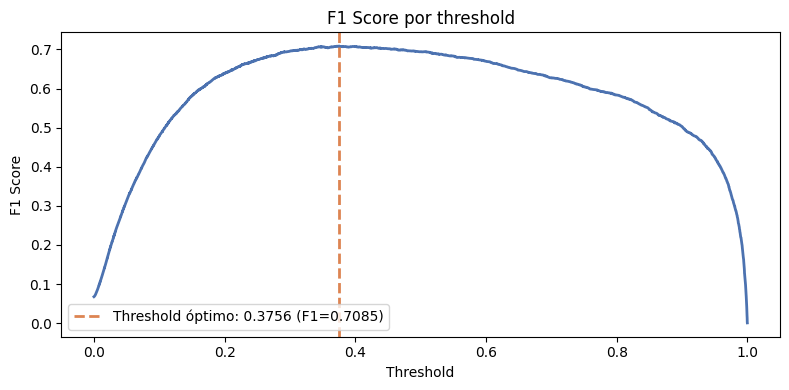

Threshold óptimo: 0.3756
F1:               0.7085


In [13]:
proba_test = model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, proba_test)

# Calcular F1 directamente sobre los arrays sin loop
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

best_idx  = np.argmax(f1_scores)
threshold = float(thresholds[best_idx])
best_f1   = float(f1_scores[best_idx])

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color="#4C72B0", linewidth=2)
plt.axvline(x=threshold, color="#DD8452", linestyle="--", linewidth=2,
            label=f"Threshold óptimo: {threshold:.4f} (F1={best_f1:.4f})")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score por threshold")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Threshold óptimo: {threshold:.4f}")
print(f"F1:               {best_f1:.4f}")

In [14]:
pred_test = (proba_test >= threshold).astype(int)

resultados_finales = {
    "modelo":                  nombre_ganador,
    "auc_pr":                  round(float(average_precision_score(y_test, proba_test)), 4),
    "roc_auc":                 round(float(roc_auc_score(y_test, proba_test)), 4),
    "f1_optimizado":           round(best_f1, 4),
    "threshold_optimo":        round(threshold, 4),
    "fraudes_detectados_test": int(((pred_test == 1) & (y_test == 1)).sum()),
    "falsos_positivos_test":   int(((pred_test == 1) & (y_test == 0)).sum())
}

with open(MODELS_DIR / "resultados_finales.json", "w") as f:
    json.dump(resultados_finales, f, indent=2)

print("Guardado en models/resultados_finales.json")
print(json.dumps(resultados_finales, indent=2))

Guardado en models/resultados_finales.json
{
  "modelo": "LightGBM",
  "auc_pr": 0.7473,
  "roc_auc": 0.9494,
  "f1_optimizado": 0.7085,
  "threshold_optimo": 0.3756,
  "fraudes_detectados_test": 1965,
  "falsos_positivos_test": 483
}


In [16]:
for t in [0.30, 0.3756, 0.45, 0.50]:
    pred             = (proba_test >= t).astype(int)
    fraudes          = int(((pred == 1) & (y_test == 1)).sum())
    falsos_positivos = int(((pred == 1) & (y_test == 0)).sum())
    f1               = round(f1_score(y_test, pred), 4)
    print(f"Threshold {t:.2f} → Fraudes detectados: {fraudes} | Falsos positivos: {falsos_positivos} | F1: {f1}")

Threshold 0.30 → Fraudes detectados: 2090 | Falsos positivos: 821 | F1: 0.6955
Threshold 0.38 → Fraudes detectados: 1965 | Falsos positivos: 483 | F1: 0.7085
Threshold 0.45 → Fraudes detectados: 1845 | Falsos positivos: 314 | F1: 0.7018
Threshold 0.50 → Fraudes detectados: 1777 | Falsos positivos: 242 | F1: 0.6944
